In [12]:
import os
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import albumentations as A
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))
!python --version

TensorFlow version: 2.18.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Python 3.12.9


In [19]:
!pwd

/home/sagemaker-user/self-driving/notebooks


In [22]:
from pathlib import Path

DATASET_DIR = Path("../dataset")
TRAIN_IMG_DIR = DATASET_DIR / "images/train"
VAL_IMG_DIR = DATASET_DIR / "images/val"
TRAIN_LABELS = DATASET_DIR / "labels/labels_train.json"
VAL_LABELS = DATASET_DIR / "labels/labels_val.json"
train_images = list(TRAIN_IMG_DIR.glob("*.jpg"))
val_images = list(VAL_IMG_DIR.glob("*.jpg"))

print(TRAIN_IMG_DIR)
print(VAL_IMG_DIR)

print("Train images:", len(train_images))
print("Val images:", len(val_images))

../dataset/images/train
../dataset/images/val
Train images: 7000
Val images: 1000


In [23]:
with open(TRAIN_LABELS) as f:
    train_labels = json.load(f)

with open(VAL_LABELS) as f:
    val_labels = json.load(f)

print("Train label entries:", len(train_labels))
print("Val label entries:", len(val_labels))

Train label entries: 69863
Val label entries: 10000


In [24]:
train_labels[0]

{'name': '0000f77c-6257be58.jpg',
 'attributes': {'weather': 'clear',
  'scene': 'city street',
  'timeofday': 'daytime'},
 'timestamp': 10000,
 'labels': [{'category': 'traffic light',
   'attributes': {'occluded': False,
    'truncated': False,
    'trafficLightColor': 'green'},
   'manualShape': True,
   'manualAttributes': True,
   'box2d': {'x1': 1125.902264,
    'y1': 133.184488,
    'x2': 1156.978645,
    'y2': 210.875445},
   'id': 0},
  {'category': 'traffic light',
   'attributes': {'occluded': False,
    'truncated': False,
    'trafficLightColor': 'green'},
   'manualShape': True,
   'manualAttributes': True,
   'box2d': {'x1': 1156.978645,
    'y1': 136.637417,
    'x2': 1191.50796,
    'y2': 210.875443},
   'id': 1},
  {'category': 'traffic sign',
   'attributes': {'occluded': False,
    'truncated': False,
    'trafficLightColor': 'none'},
   'manualShape': True,
   'manualAttributes': True,
   'box2d': {'x1': 1101.731743,
    'y1': 211.122087,
    'x2': 1170.79037,
    

In [28]:
print(train_images[0])

../dataset/images/train/00e9be89-00001060.jpg


(-0.5, 1279.5, 719.5, -0.5)

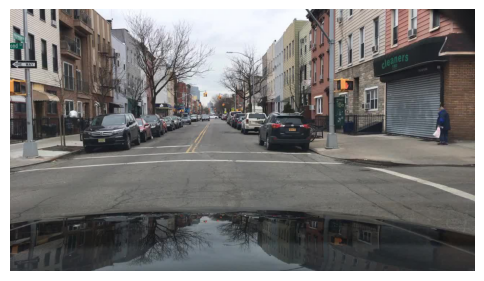

In [30]:
import random

img_path = random.choice(train_images)

img = cv2.imread(str(img_path))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")

In [32]:
image_names = {p.name for p in train_images}

In [33]:
filtered_labels = [l for l in train_labels if l["name"] in image_names]

print("Original labels:", len(train_labels))
print("Filtered labels:", len(filtered_labels))

Original labels: 69863
Filtered labels: 2972


(-0.5, 1279.5, 719.5, -0.5)

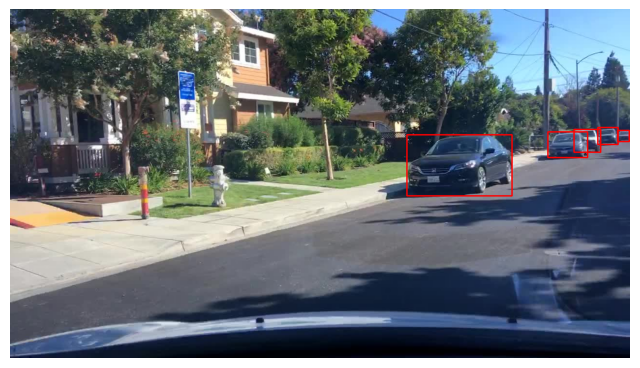

In [34]:
sample = filtered_labels[0]

img_path = TRAIN_IMG_DIR / sample["name"]

img = cv2.imread(str(img_path))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

for obj in sample["labels"]:
    
    if "box2d" not in obj:
        continue
        
    box = obj["box2d"]
    
    x1,y1,x2,y2 = int(box["x1"]), int(box["y1"]), int(box["x2"]), int(box["y2"])
    
    cv2.rectangle(img,(x1,y1),(x2,y2),(255,0,0),2)

plt.figure(figsize=(8,6))
plt.imshow(img)
plt.axis("off")

In [35]:
missing = [l["name"] for l in train_labels if not (TRAIN_IMG_DIR / l["name"]).exists()]
print("Missing labels:", len(missing))

Missing labels: 66891


In [36]:
img = cv2.imread(str(img_path))

if img is None:
    raise ValueError(f"Image not found: {img_path}")

In [37]:
categories = []

for item in train_labels:
    for obj in item.get("labels", []):
        categories.append(obj["category"])

cat_series = pd.Series(categories)

print(cat_series.value_counts().head(10))

car              713211
lane             528643
traffic sign     239686
traffic light    186117
drivable area    125723
person            91349
truck             29971
bus               11672
bike               7210
rider              4517
Name: count, dtype: int64


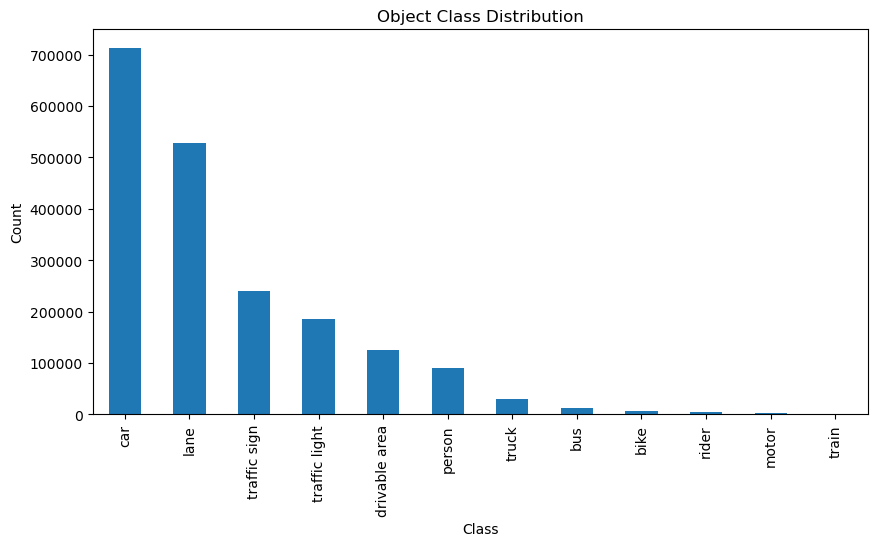

In [38]:
plt.figure(figsize=(10,5))
cat_series.value_counts().plot(kind="bar")
plt.title("Object Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

Text(0.5, 1.0, 'Bounding Box Distribution')

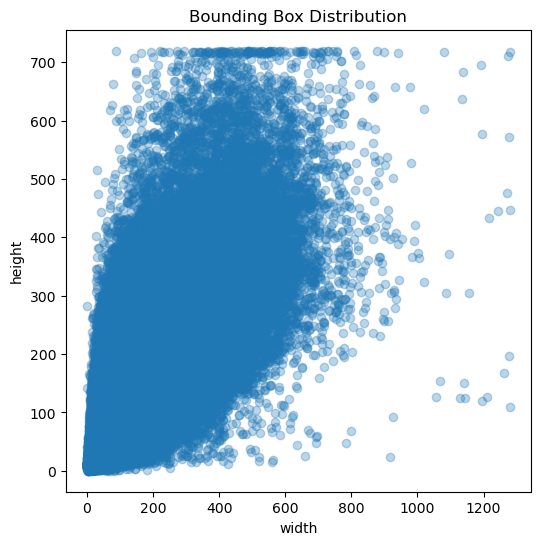

In [39]:
widths = []
heights = []

for item in train_labels:
    for obj in item.get("labels", []):
        
        if "box2d" not in obj:
            continue
        
        box = obj["box2d"]
        
        w = box["x2"] - box["x1"]
        h = box["y2"] - box["y1"]
        
        widths.append(w)
        heights.append(h)

plt.figure(figsize=(6,6))
plt.scatter(widths, heights, alpha=0.3)
plt.xlabel("width")
plt.ylabel("height")
plt.title("Bounding Box Distribution")

In [40]:
img = cv2.imread(str(train_images[0]))
print(img.shape)

(720, 1280, 3)
